# executorlib

[`executorlib`](https://executorlib.readthedocs.io/en/latest/) is a lightweight workflow engine built directly on Python's standard `concurrent.futures` interface: instead of a bespoke node/graph API, you `submit()` plain functions to an executor and get back `Future` objects, exactly as with `concurrent.futures.ThreadPoolExecutor` or `ProcessPoolExecutor`. The same executor interface scales from a single laptop core (`SingleNodeExecutor`) up to HPC clusters via Flux or SLURM, without changing the workflow code itself. This notebook rebuilds the same [`workflow.py`](workflow.py) analysis from [`python.ipynb`](python.ipynb) with `executorlib`.

### References

- Janssen, J., Taylor, M. G., Yang, P., Neugebauer, J., & Perez, D. (2025). Executorlib – Up-scaling Python workflows for hierarchical heterogenous high-performance computing. Journal of Open Source Software, 10(108), 7782. https://doi.org/10.21105/joss.07782

In [1]:
from concurrent.futures import Future
import executorlib 
from workflow import read_csv, calculate_youngs_modulus, convert_load_to_stress, plot

## Asynchronous Programming

`executorlib` builds on Python's built-in `concurrent.futures.Future`: a placeholder for a result that may not be available yet. A `Future` starts "not done"; once a result is set, `done()` becomes `True` and `result()` returns the value. `executorlib`'s `submit()` returns exactly this kind of object, so any code that already understands `concurrent.futures` immediately understands `executorlib`.

In [2]:
f = Future()

In [3]:
f.done()

False

In [4]:
f.set_result(5)

In [5]:
f.done()

True

In [6]:
f.result()

5

## Workflow

Submitting a function returns a `Future` immediately, without blocking; passing that `Future` as an argument to the next `exe.submit()` call tells `executorlib` to wait for it and wire the result in — the dependency graph is implicit in how the futures are passed around, rather than declared explicitly as it was with `pyiron_workflow`. Because `convert_load_to_stress` returns a dictionary, `executorlib.get_item_from_future()` is used to reference a single entry (`"stress"` or `"strain"`) of a still-pending result.

In [7]:
area = 120
strain_cutoff = 0.2
filename = "./data/dataset_1.csv"

175.1800847629701


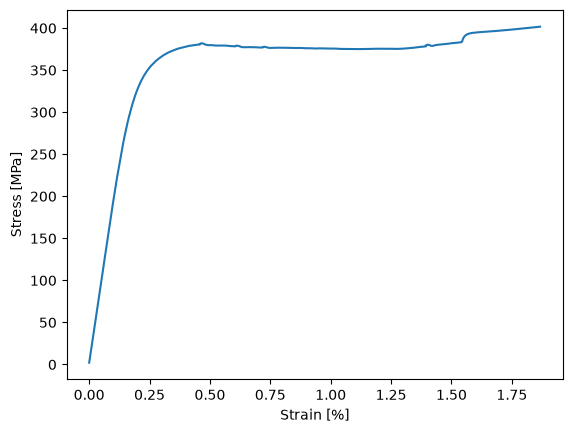

In [8]:
with executorlib.SingleNodeExecutor(cache_directory="./cache") as exe:
    # df = read_csv(filename=filename)
    df_future = exe.submit(read_csv, filename=filename)
    # stress, strain = convert_load_to_stress(df=df, area=area)
    convert_future = exe.submit(convert_load_to_stress, df=df_future, area=area)
    stress_future = executorlib.get_item_from_future(future=convert_future, key="stress")
    strain_future = executorlib.get_item_from_future(future=convert_future, key="strain")
    # youngs_modulus = calculate_youngs_modulus(stress=stress, strain=strain, strain_cutoff=strain_cutoff)
    youngs_modulus_future = exe.submit(calculate_youngs_modulus, stress=stress_future, strain=strain_future, strain_cutoff=strain_cutoff)
    print(youngs_modulus_future.result())
    # plot(stress=stress, strain=strain, format="-");
    plot_future = exe.submit(plot, stress=stress_future, strain=strain_future, format="-")
    plot_future.result()

## Workflow Graph

Passing `plot_dependency_graph=True` visualizes the dependency graph that `executorlib` inferred from the futures above — the same graph structure that `pyiron_workflow.ipynb` builds explicitly with a `Workflow` object.

None


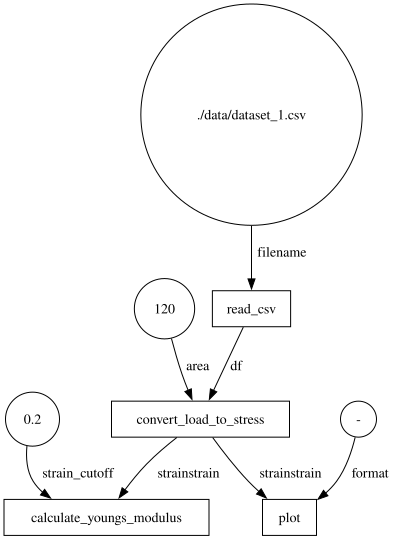

In [9]:
with executorlib.SingleNodeExecutor(plot_dependency_graph=True) as exe:
    df_future = exe.submit(read_csv, filename="./data/dataset_1.csv")
    convert_future = exe.submit(convert_load_to_stress, df=df_future, area=area)
    stress_future = executorlib.get_item_from_future(future=convert_future, key="stress")
    strain_future = executorlib.get_item_from_future(future=convert_future, key="strain")
    youngs_modulus_future = exe.submit(calculate_youngs_modulus, stress=stress_future, strain=strain_future, strain_cutoff=strain_cutoff)
    plot_future = exe.submit(plot, stress=stress_future, strain=strain_future, format="-")
    print(youngs_modulus_future.result())
    plot_future.result()

## High Performance Computing

Swapping `SingleNodeExecutor` for `SlurmClusterExecutor` (or a flux equivalent) submits the exact same tasks as jobs to an HPC scheduler instead of running them locally — the workflow code itself does not change. The cell below is kept as a raw, non-executed cell, since running it requires a SLURM cluster to submit to.

## Python Workflow Definition

As with `pyiron_workflow`, the submitted tasks can be exported to the engine-agnostic [Python Workflow Definition](https://pythonworkflow.github.io/python-workflow-definition/) JSON format by passing `export_workflow_filename`, and reloaded with `load_workflow_json()`. Compare the `workflow.json` produced below to the one produced in [`pyiron_workflow.ipynb`](pyiron_workflow.ipynb): both describe the same graph of plain functions from [`workflow.py`](workflow.py), which is exactly what allows a workflow built with one engine to be executed by the other.

### References

- Janssen, J., George, J., Geiger, J., Bercx, M., Wang, X., Ertural, C., Schaarschmidt, J., Ganose, A. M., Pizzi, G., Hickel, T., & Neugebauer, J. (2025). A Python workflow definition for computational materials design. Digital Discovery. https://doi.org/10.1039/d5dd00231a

In [10]:
with executorlib.SingleNodeExecutor(export_workflow_filename="workflow.json") as exe:
    df_future = exe.submit(read_csv, filename="./data/dataset_1.csv")
    convert_future = exe.submit(convert_load_to_stress, df=df_future, area=area)
    stress_future = executorlib.get_item_from_future(future=convert_future, key="stress")
    strain_future = executorlib.get_item_from_future(future=convert_future, key="strain")
    youngs_modulus_future = exe.submit(calculate_youngs_modulus, stress=stress_future, strain=strain_future, strain_cutoff=strain_cutoff)
    plot_future = exe.submit(plot, stress=stress_future, strain=strain_future, format="-")
    print(youngs_modulus_future.result())
    plot_future.result()

None


In [11]:
!cat workflow.json

{
    "version": "0.1.0",
    "nodes": [
        {
            "id": 0,
            "type": "function",
            "value": "workflow.read_csv"
        },
        {
            "id": 1,
            "type": "function",
            "value": "workflow.convert_load_to_stress"
        },
        {
            "id": 2,
            "type": "function",
            "value": "workflow.calculate_youngs_modulus"
        },
        {
            "id": 3,
            "type": "function",
            "value": "workflow.plot"
        },
        {
            "id": 4,
            "type": "input",
            "value": "./data/dataset_1.csv",
            "name": "filename"
        },
        {
            "id": 5,
            "type": "input",
            "value": 120,
            "name": "area"
        },
        {
            "id": 6,
            "type": "input",
            "value": 0.2,
            "name": "strain_cutoff"
        },
        {
            "id": 7,
            "type": "input",
         

In [12]:
from python_workflow_definition.executorlib import load_workflow_json

175.1800847629701


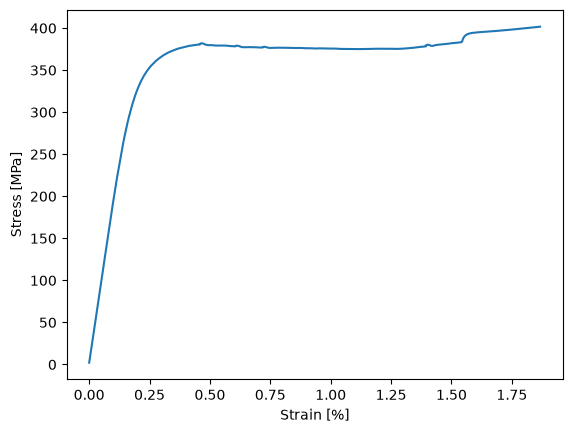

In [13]:
with executorlib.SingleNodeExecutor() as exe:
    future = load_workflow_json(file_name="workflow.json", exe=exe)
    print(future.result())

## Summary

Across these four notebooks the same [`workflow.py`](workflow.py) functions were executed as a plain Python module, as a `pyiron_workflow` graph — inspected either in code or through `pyironflow`'s graphical interface — and as `executorlib` futures — first on a laptop and, in principle, on an HPC cluster. The [Python Workflow Definition](https://pythonworkflow.github.io/python-workflow-definition/) is what ties them together: a single JSON description of a workflow that any compatible engine can read and execute.